<a href="https://colab.research.google.com/github/shravanisci/Colon-Cancer-Metastasis-Analysis/blob/main/CT_Runthrough.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RNA-seq Analysis of Human Cancer Data from GEO

This notebook will guide you through performing a complete RNA-seq analysis on a human cancer dataset obtained directly from the Gene Expression Omnibus (GEO) database. We will cover the following key steps:

1.  **Data Acquisition**: Downloading raw sequencing data (SRA files) using the SRA Toolkit.
2.  **Quality Control**: Assessing the quality of raw reads using FastQC.
3.  **Alignment**: Mapping reads to a reference human genome (e.g., GRCh38) using a tool like STAR or HISAT2.
4.  **Quantification**: Counting reads per gene using featureCounts or pseudo-alignment with Salmon/Kallisto.
5.  **Differential Gene Expression Analysis**: Identifying significantly up- or down-regulated genes using `DESeq2` (via `pydeseq2`).
6.  **Functional Enrichment Analysis**: Performing Gene Ontology (GO) and pathway enrichment analysis on differentially expressed genes.
7.  **Visualization**: Creating plots like Volcano Plots, Heatmaps, and Principal Component Analysis (PCA) to interpret results.

## Step 1: Specify GEO Dataset and Set Up Environment

First, please provide the **GEO accession ID** of the human cancer dataset you wish to analyze (e.g., `GSE12345`). This ID will allow us to fetch the relevant metadata and sequencing data.

In [1]:
# Define the GEO accession ID
GEO_ACCESSION_ID = 'GSE50760'
print(f"Using GEO Accession ID: {GEO_ACCESSION_ID}")

Using GEO Accession ID: GSE50760


## Step 2: Install SRA Toolkit

To download the raw sequencing data (SRA files), we'll use the SRA Toolkit from NCBI. This suite of tools allows us to access and process data from the Sequence Read Archive.

In [4]:
!sudo apt-get update
!sudo apt-get install sra-toolkit -y

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [3,033 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,311 kB]
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [7,400 kB]
Get:14 http://security

## Step 3: Retrieve SRA Accession IDs

Before downloading the data, we need to find the specific SRA (Sequence Read Archive) run accession IDs that correspond to our GEO dataset (`GSE50760`). These IDs represent the raw sequencing files.

In [12]:
# Fetch SRA accession IDs for the given GEO_ACCESSION_ID
# This command uses esearch to find the GEO entry, efetch to get its associated SRA entries,
# and then extracts the run accessions (SRR IDs).

sra_accessions_output = !/usr/bin/esearch -db sra -query "{GEO_ACCESSION_ID}" | /usr/bin/efetch -format runinfo | cut -d ',' -f 1 | grep SRR

# Convert the output to a Python list and remove any empty strings
sra_accessions = [acc.strip() for acc in sra_accessions_output if acc.strip()]

print(f"Found {len(sra_accessions)} SRA accessions for {GEO_ACCESSION_ID}:")
if sra_accessions:
    for accession in sra_accessions:
        print(accession)
else:
    print("No SRA accessions found. Please check the GEO Accession ID or the output for errors.")

# Store the SRA accessions in a variable for later use
SRA_ACCESSION_LIST = sra_accessions

Found 4 SRA accessions for GSE50760:
curl: (56) OpenSSL SSL_read: error:0A000126:SSL routines::unexpected eof while reading, errno 0
ERROR: curl command failed ( Sun May 31 02:39:42 PM UTC 2026 ) with: 56
https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi -d retmax=0&usehistory=y&db=sra&term=GSE50760&tool=edirect&edirect=14.6&edirect_os=Linux&email=root%40138b088c5225
HTTP/1.0 200 OK


In [11]:
import os
import re

# Find the actual path of esearch and efetch
esearch_path = !which esearch
efetch_path = !which efetch

if esearch_path and efetch_path:
    ESEARCH_BIN = esearch_path[0].strip()
    EFETCH_BIN = efetch_path[0].strip()
    print(f"Found esearch at: {ESEARCH_BIN}")
    print(f"Found efetch at: {EFETCH_BIN}")
else:
    ESEARCH_BIN = '/usr/bin/esearch' # Fallback
    EFETCH_BIN = '/usr/bin/efetch'   # Fallback
    print("Could not find esearch/efetch in PATH. Using default fallback paths.")

# Now, re-run the command using the dynamically found paths
# We remove the final grep SRR and filter within Python for more control
sra_accessions_raw_output = !{ESEARCH_BIN} -db sra -query "{GEO_ACCESSION_ID}" | {EFETCH_BIN} -format runinfo | cut -d ',' -f 1

sra_accessions = []
error_messages = []

for line in sra_accessions_raw_output:
    cleaned_line = line.strip()
    # Check if the line starts with 'SRR' to identify actual SRA accessions
    if cleaned_line.startswith('SRR'):
        sra_accessions.append(cleaned_line)
    elif cleaned_line: # Capture non-empty lines that are not SRR as potential errors
        error_messages.append(cleaned_line)

print(f"Found {len(sra_accessions)} SRA accessions for {GEO_ACCESSION_ID}:")
if sra_accessions:
    for accession in sra_accessions:
        print(accession)
else:
    print("No SRA accessions found. Please check the GEO Accession ID or the output for errors.")
    if error_messages:
        print("\nPossible errors/warnings from EDirect:")
        for msg in error_messages:
            print(msg)

# Store the SRA accessions in a variable for later use
SRA_ACCESSION_LIST = sra_accessions

Found esearch at: /usr/bin/esearch
Found efetch at: /usr/bin/efetch
Found 0 SRA accessions for GSE50760:
No SRA accessions found. Please check the GEO Accession ID or the output for errors.

Possible errors/warnings from EDirect:
curl: (56) OpenSSL SSL_read: error:0A000126:SSL routines::unexpected eof while reading, errno 0
ERROR: curl command failed ( Sun May 31 02:39:35 PM UTC 2026 ) with: 56
https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi -d retmax=0&usehistory=y&db=sra&term=GSE50760&tool=edirect&edirect=14.6&edirect_os=Linux&email=root%40138b088c5225
HTTP/1.0 200 OK


## Step 3 (Revised): Extract Raw Data

Since the SRA accessions couldn't be retrieved programmatically and you've directly provided a processed `.tar` file, we'll proceed by extracting its contents. This file likely contains the raw count data or other processed files for `GSE50760`.

In [13]:
# Define the path to the downloaded tar file
TAR_FILE = '/content/GSE50760_RAW.tar'

# Create a directory to extract the files into
EXTRACT_DIR = './GSE50760_RAW_data'
!mkdir -p {EXTRACT_DIR}

# Extract the tar file
print(f"Extracting {TAR_FILE} to {EXTRACT_DIR}...")
!tar -xvf {TAR_FILE} -C {EXTRACT_DIR}
print("Extraction complete.")

# List the contents of the extracted directory to see what we have
print(f"\nContents of {EXTRACT_DIR}:")
!ls -lh {EXTRACT_DIR}

Extracting /content/GSE50760_RAW.tar to ./GSE50760_RAW_data...
GSM1228184_AMC_2.1_FPKM.txt.gz
GSM1228185_AMC_3.1_FPKM.txt.gz
GSM1228186_AMC_5.1_FPKM.txt.gz
GSM1228187_AMC_6.1_FPKM.txt.gz
GSM1228188_AMC_7.1_FPKM.txt.gz
GSM1228189_AMC_8.1_FPKM.txt.gz
GSM1228190_AMC_9.1_FPKM.txt.gz
GSM1228191_AMC_10.1_FPKM.txt.gz
GSM1228192_AMC_12.1_FPKM.txt.gz
GSM1228193_AMC_13.1_FPKM.txt.gz
GSM1228194_AMC_17.1_FPKM.txt.gz
GSM1228195_AMC_18.1_FPKM.txt.gz
GSM1228196_AMC_19.1_FPKM.txt.gz
GSM1228197_AMC_20.1_FPKM.txt.gz
GSM1228198_AMC_21.1_FPKM.txt.gz
GSM1228199_AMC_22.1_FPKM.txt.gz
GSM1228200_AMC_23.1_FPKM.txt.gz
GSM1228201_AMC_24.1_FPKM.txt.gz
GSM1228202_AMC_2.2_FPKM.txt.gz
GSM1228203_AMC_3.2_FPKM.txt.gz
GSM1228204_AMC_5.2_FPKM.txt.gz
GSM1228205_AMC_6.2_FPKM.txt.gz
GSM1228206_AMC_7.2_FPKM.txt.gz
GSM1228207_AMC_8.2_FPKM.txt.gz
GSM1228208_AMC_9.2_FPKM.txt.gz
GSM1228209_AMC_10.2_FPKM.txt.gz
GSM1228210_AMC_12.2_FPKM.txt.gz
GSM1228211_AMC_13.2_FPKM.txt.gz
GSM1228212_AMC_17.2_FPKM.txt.gz
GSM1228213_AMC_18.2_FPK

## Step 4: Load Gene Expression Data

The extracted directory contains individual FPKM (Fragments Per Kilobase Million) `.txt.gz` files for each sample. We need to read these files and combine them into a single gene expression matrix. We'll use pandas to load and merge this data.

In [22]:
import pandas as pd
import os
import glob

print(f"Current working directory: {os.getcwd()}")
# Ensure EXTRACT_DIR is an absolute path to avoid any ambiguity
EXTRACT_DIR_ABS = os.path.abspath(EXTRACT_DIR)
print(f"Checking absolute directory: {EXTRACT_DIR_ABS}")

# List contents of EXTRACT_DIR to verify files are there
print("Contents of EXTRACT_DIR (using os.listdir) and endswith check:")
all_files_in_dir = []
sample_filename_for_debug = None
EXPECTED_SUFFIX = '_FPKM.txt.gz' # Corrected suffix here

try:
    for f_name_raw in os.listdir(EXTRACT_DIR_ABS):
        # Aggressively clean filename: remove null bytes and then strip whitespace
        f_name_cleaned = f_name_raw.replace('\x00', '').strip()
        full_path = os.path.join(EXTRACT_DIR_ABS, f_name_cleaned)
        all_files_in_dir.append(full_path)
        ends_with_check = f_name_cleaned.endswith(EXPECTED_SUFFIX)

        print(f"  Raw File: '{f_name_raw}' (len: {len(f_name_raw)}), Cleaned: '{f_name_cleaned}' (len: {len(f_name_cleaned)}), ends_with_{EXPECTED_SUFFIX.replace('.', '_')}: {ends_with_check}")
        if sample_filename_for_debug is None:
            sample_filename_for_debug = f_name_raw
except FileNotFoundError:
    print(f"Error: Directory {EXTRACT_DIR_ABS} not found.")

if sample_filename_for_debug:
    # Re-clean the sample filename for focused debug output
    cleaned_sample_filename = sample_filename_for_debug.replace('\x00', '').strip()
    print(f"\nDebugging sample filename: repr('{sample_filename_for_debug}') -> {repr(sample_filename_for_debug)}")
    print(f"  Cleaned sample filename repr: {repr(cleaned_sample_filename)}")
    print(f"Expected suffix: '{EXPECTED_SUFFIX}'")
    print(f"Is it present after cleaning?: {cleaned_sample_filename.endswith(EXPECTED_SUFFIX)}")
    if len(cleaned_sample_filename) >= len(EXPECTED_SUFFIX):
        actual_suffix_part = cleaned_sample_filename[-len(EXPECTED_SUFFIX):]
        print(f"  Expected suffix part repr: {repr(EXPECTED_SUFFIX)}")
        print(f"  Actual suffix part repr (from cleaned name): {repr(actual_suffix_part)}")
        print(f"  Suffixes are equal after cleaning: {actual_suffix_part == EXPECTED_SUFFIX}")

# Get a list of all FPKM files using glob
# Glob might also be affected by invisible characters, so we'll rely more on manual filtering now.
glob_pattern = os.path.join(EXTRACT_DIR_ABS, f'*{EXPECTED_SUFFIX}')
print(f"\nGlob pattern used: '{glob_pattern}'")
fpkm_files_glob = glob.glob(glob_pattern)

if not fpkm_files_glob:
    print(f"glob.glob found {len(fpkm_files_glob)} FPKM files with pattern '{glob_pattern}'. This is expected if invisible chars are present.")
    print("Attempting manual filtering with aggressive cleaning as fallback...")
    # Manually filter from all_files_in_dir, cleaning filenames before checking suffix
    fpkm_files = []
    for f_path_raw in os.listdir(EXTRACT_DIR_ABS):
        f_name_cleaned = f_path_raw.replace('\x00', '').strip()
        if f_name_cleaned.endswith(EXPECTED_SUFFIX):
            # Append the full path with the cleaned filename for consistency
            fpkm_files.append(os.path.join(EXTRACT_DIR_ABS, f_name_cleaned))

    if not fpkm_files:
        print("Manual filtering with aggressive cleaning also found no FPKM files. This is highly unusual.")
    else:
        print(f"Manual filtering with aggressive cleaning succeeded, found {len(fpkm_files)} FPKM files.")
else:
    print(f"Glob found {len(fpkm_files_glob)} FPKM files.")
    fpkm_files = fpkm_files_glob


if not fpkm_files:
    print("FATAL: No FPKM data could be found or loaded.")
else:
    print(f"\nFound {len(fpkm_files)} FPKM files. Loading data...")

    # Initialize an empty list to store individual dataframes
    all_fpkm_dfs = []

    for file_path in fpkm_files:
        # Ensure we are cleaning the basename when extracting sample_id as well
        # os.path.basename(file_path) will already be clean if coming from our fpkm_files list
        sample_id = os.path.basename(file_path).replace(EXPECTED_SUFFIX, '')

        # Read the FPKM file. Assuming it's a tab-separated file with gene names in the first column
        # and FPKM values in the second (or similar simple structure).
        try:
            # Read only the first few lines to infer structure
            # The 'compression' parameter handles .gz files automatically
            df_sample = pd.read_csv(file_path, sep='\t', header=None, names=['GeneID', sample_id], index_col=0, compression='gzip')

            # Print first few lines after successful loading for verification
            print(f"\nSuccessfully loaded {sample_id}. First 5 rows:")
            print(df_sample.head())

            all_fpkm_dfs.append(df_sample)
        except Exception as e:
            print(f"Error loading {file_path}: {e}")

    if all_fpkm_dfs:
        # Concatenate all dataframes into a single expression matrix
        expression_df = pd.concat(all_fpkm_dfs, axis=1)

        # Display the shape and first few rows of the combined dataframe
        print(f"\nCombined expression matrix shape: {expression_df.shape}")
        print("First 5 rows of the expression matrix:")
        print(expression_df.head())

        # Store the expression data for further steps
        GENE_EXPRESSION_DF = expression_df
    else:
        print("No FPKM data could be combined into a DataFrame.")

Current working directory: /content
Checking absolute directory: /content/GSE50760_RAW_data
Contents of EXTRACT_DIR (using os.listdir) and endswith check:
  Raw File: 'GSM1228213_AMC_18.2_FPKM.txt.gz' (len: 31), Cleaned: 'GSM1228213_AMC_18.2_FPKM.txt.gz' (len: 31), ends_with__FPKM_txt_gz: True
  Raw File: 'GSM1228217_AMC_22.2_FPKM.txt.gz' (len: 31), Cleaned: 'GSM1228217_AMC_22.2_FPKM.txt.gz' (len: 31), ends_with__FPKM_txt_gz: True
  Raw File: 'GSM1228192_AMC_12.1_FPKM.txt.gz' (len: 31), Cleaned: 'GSM1228192_AMC_12.1_FPKM.txt.gz' (len: 31), ends_with__FPKM_txt_gz: True
  Raw File: 'GSM1228201_AMC_24.1_FPKM.txt.gz' (len: 31), Cleaned: 'GSM1228201_AMC_24.1_FPKM.txt.gz' (len: 31), ends_with__FPKM_txt_gz: True
  Raw File: 'GSM1228184_AMC_2.1_FPKM.txt.gz' (len: 30), Cleaned: 'GSM1228184_AMC_2.1_FPKM.txt.gz' (len: 30), ends_with__FPKM_txt_gz: True
  Raw File: 'GSM1228188_AMC_7.1_FPKM.txt.gz' (len: 30), Cleaned: 'GSM1228188_AMC_7.1_FPKM.txt.gz' (len: 30), ends_with__FPKM_txt_gz: True
  Raw Fil

## Step 5: Load Sample Metadata

Now that we have the gene expression data, we need to load the corresponding sample metadata from GEO. This metadata contains critical information about each sample, such as experimental group, tissue type, or treatment conditions, which is essential for differential expression analysis.

In [26]:
import pandas as pd
import os
import gzip

# 1. Download the Series Matrix file directly from NCBI FTP
matrix_url = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE50nnn/GSE50760/matrix/GSE50760_series_matrix.txt.gz"
!wget -q {matrix_url} -O GSE50760_series_matrix.txt.gz

# 2. Parse the metadata lines (lines starting with !Sample_)
metadata_dict = {}
with gzip.open("GSE50760_series_matrix.txt.gz", "rt") as f:
    for line in f:
        if line.startswith("!Sample_title"):
            metadata_dict["sample_title"] = line.strip().split("\t")[1:]
        elif line.startswith("!Sample_geo_accession"):
            metadata_dict["gsm_id"] = line.strip().split("\t")[1:]
        elif line.startswith("!Sample_characteristics_ch1"):
            # GEO often has multiple characteristics lines; let's capture them dynamically
            key = f"characteristics_{len([k for k in metadata_dict if 'characteristics' in k])}"
            metadata_dict[key] = line.strip().split("\t")[1:]
        elif line.startswith("!series_matrix_table_begin"):
            # Stop reading once the massive expression table starts
            break

# 3. Build the Metadata DataFrame
SAMPLE_METADATA_DF = pd.DataFrame(metadata_dict)

# Clean up column names and string formatting neatly
SAMPLE_METADATA_DF.columns = [col.lower().replace(" ", "_") for col in SAMPLE_METADATA_DF.columns]

print(f"Successfully loaded metadata for {len(SAMPLE_METADATA_DF)} samples!")
display(SAMPLE_METADATA_DF.head())

Successfully loaded metadata for 54 samples!


,sample_title,gsm_id,characteristics_0,characteristics_1
0,"""primary colorectal cancer AMC_2-1""","""GSM1228184""","""tissue: primary colorectal cancer""","""ajcc stage: Stage IV"""
1,"""primary colorectal cancer AMC_3-1""","""GSM1228185""","""tissue: primary colorectal cancer""","""ajcc stage: Stage IV"""
2,"""primary colorectal cancer AMC_5-1""","""GSM1228186""","""tissue: primary colorectal cancer""","""ajcc stage: Stage IV"""
3,"""primary colorectal cancer AMC_6-1""","""GSM1228187""","""tissue: primary colorectal cancer""","""ajcc stage: Stage IV"""
4,"""primary colorectal cancer AMC_7-1""","""GSM1228188""","""tissue: primary colorectal cancer""","""ajcc stage: Stage IV"""


## Step 6: Data Integration and Preprocessing

With both the gene expression data (`GENE_EXPRESSION_DF`) and the sample metadata (`SAMPLE_METADATA_DF`) loaded, we need to integrate these two datasets. This involves ensuring that the sample identifiers are consistent across both tables and then merging them so that each gene expression column is associated with its correct sample characteristics.

We will also perform initial data cleaning and preparation, such as ensuring data types are correct and handling any obvious discrepancies.

In [28]:
import numpy as np
import re

# Transpose GENE_EXPRESSION_DF so samples are rows and genes are columns
# This makes it easier to merge with metadata where each row is a sample.

# Drop the row with 'genes' in the index if it exists, then transpose.
# The 'genes' row contains metadata about the FPKM files themselves, not gene expression.
if 'genes' in GENE_EXPRESSION_DF.index:
    expression_t = GENE_EXPRESSION_DF.drop(index='genes').T
else:
    expression_t = GENE_EXPRESSION_DF.T

# Ensure the index (sample IDs) of the transposed expression data are strings
expression_t.index = expression_t.index.astype(str)

# PROBLEM: The sample IDs in expression_t.index are like 'GSM1228213_AMC_18.2'
# while metadata 'gsm_id_cleaned' are like 'GSM1228184'.
# We need to extract only the 'GSM' part from the expression_t index.

# Extract base GSM ID from expression_t index (e.g., 'GSM1228213_AMC_18.2' -> 'GSM1228213')
def extract_gsm_id(sample_full_id):
    match = re.match(r'(GSM\d+)', sample_full_id)
    if match:
        return match.group(1)
    return None

expression_t['gsm_id_extracted'] = [extract_gsm_id(idx) for idx in expression_t.index]
expression_t = expression_t.set_index('gsm_id_extracted')
# Drop the temporary column and set the index. Handle potential None if extraction fails for some.
expression_t = expression_t[expression_t.index.notna()]

# Clean sample IDs in metadata_df to match expression_t index
# The gsm_id in SAMPLE_METADATA_DF might have quotes or leading/trailing spaces
SAMPLE_METADATA_DF['gsm_id_cleaned'] = SAMPLE_METADATA_DF['gsm_id'].str.replace('"', '').str.strip()

# Align sample IDs by finding common IDs between expression data and metadata
common_sample_ids = list(set(expression_t.index) & set(SAMPLE_METADATA_DF['gsm_id_cleaned']))

print(f"Number of samples in expression data: {expression_t.shape[0]}")
print(f"Number of samples in metadata: {SAMPLE_METADATA_DF.shape[0]}")
print(f"Number of common samples: {len(common_sample_ids)}")

# Filter both dataframes to include only common samples
# Ensure the order of samples is consistent for merging by using .loc and sorting
expression_filtered = expression_t.loc[common_sample_ids].sort_index()
metadata_filtered = SAMPLE_METADATA_DF[SAMPLE_METADATA_DF['gsm_id_cleaned'].isin(common_sample_ids)]

# Set 'gsm_id_cleaned' as index for metadata for easy merging
metadata_filtered = metadata_filtered.set_index('gsm_id_cleaned').sort_index()

# Merge the expression data with the metadata
# The `axis=1` means merging columns, matching on index (sample IDs)
MERGED_DATA_DF = pd.merge(expression_filtered, metadata_filtered, left_index=True, right_index=True)

print(f"\nShape of merged dataset: {MERGED_DATA_DF.shape}")
print("First 5 rows of merged dataset (expression values and metadata):")
display(MERGED_DATA_DF.head())

Number of samples in expression data: 54
Number of samples in metadata: 54
Number of common samples: 54

Shape of merged dataset: (54, 23509)
First 5 rows of merged dataset (expression values and metadata):


,A1BG,A1BG-AS1,A1CF,A2LD1,A2M,A2ML1,A2MP1,A4GALT,A4GNT,AA06,...,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,sample_title,gsm_id,characteristics_0,characteristics_1
gsm_id_extracted,,,,,,,,,,,,,,,,,,,,,
GSM1228184,0.241109,0.0281731,16.257,1.56614,33.1469,0,0,0.70743,0,0,...,5.88682,0.0537722,3.4685,27.7184,7.25732,6.29149,"""primary colorectal cancer AMC_2-1""","""GSM1228184""","""tissue: primary colorectal cancer""","""ajcc stage: Stage IV"""
GSM1228185,0.413634,0.0216056,12.4223,4.62522,46.8375,0,0.0296773,1.015,0,0,...,6.49676,0,3.40096,38.484,7.3298,8.53705,"""primary colorectal cancer AMC_3-1""","""GSM1228185""","""tissue: primary colorectal cancer""","""ajcc stage: Stage IV"""
GSM1228186,0.773777,0.149216,4.63792,3.55649,114.636,0,0,3.55672,0,0,...,4.93464,0.0110013,3.58314,28.372,13.0043,5.18621,"""primary colorectal cancer AMC_5-1""","""GSM1228186""","""tissue: primary colorectal cancer""","""ajcc stage: Stage IV"""
GSM1228187,0.290182,0.0540382,4.21296,6.13582,37.3062,0.00562125,0,3.07267,0,0,...,4.16064,0.0167459,3.1634,96.1591,4.25974,6.13764,"""primary colorectal cancer AMC_6-1""","""GSM1228187""","""tissue: primary colorectal cancer""","""ajcc stage: Stage IV"""
GSM1228188,0.508287,0.0835401,5.01399,6.76977,22.5658,0,0,1.03725,0,0,...,5.27769,0.0331415,3.63845,60.8978,5.33932,5.98535,"""primary colorectal cancer AMC_7-1""","""GSM1228188""","""tissue: primary colorectal cancer""","""ajcc stage: Stage IV"""


## Step 7: Define Comparison Groups for Differential Gene Expression Analysis

To perform differential gene expression analysis, we need to define our experimental groups. Based on the user's request, we will compare 'liver metastasis' samples against 'primary colorectal cancer' samples. We need to identify the appropriate column in the `SAMPLE_METADATA_DF` (or `MERGED_DATA_DF`) that contains this grouping information and extract the relevant labels.

In [29]:
# Inspect the unique values in relevant metadata columns to identify comparison groups
print("Unique values in 'sample_title' column:")
display(SAMPLE_METADATA_DF['sample_title'].unique())

print("\nUnique values in 'characteristics_0' column:")
display(SAMPLE_METADATA_DF['characteristics_0'].unique())

print("\nUnique values in 'characteristics_1' column:")
display(SAMPLE_METADATA_DF['characteristics_1'].unique())

Unique values in 'sample_title' column:


array(['"primary colorectal cancer AMC_2-1"',
       '"primary colorectal cancer AMC_3-1"',
       '"primary colorectal cancer AMC_5-1"',
       '"primary colorectal cancer AMC_6-1"',
       '"primary colorectal cancer AMC_7-1"',
       '"primary colorectal cancer AMC_8-1"',
       '"primary colorectal cancer AMC_9-1"',
       '"primary colorectal cancer AMC_10-1"',
       '"primary colorectal cancer AMC_12-1"',
       '"primary colorectal cancer AMC_13-1"',
       '"primary colorectal cancer AMC_17-1"',
       '"primary colorectal cancer AMC_18-1"',
       '"primary colorectal cancer AMC_19-1"',
       '"primary colorectal cancer AMC_20-1"',
       '"primary colorectal cancer AMC_21-1"',
       '"primary colorectal cancer AMC_22-1"',
       '"primary colorectal cancer AMC_23-1"',
       '"primary colorectal cancer AMC_24-1"', '"normal colon AMC_2-2"',
       '"normal colon AMC_3-2"', '"normal colon AMC_5-2"',
       '"normal colon AMC_6-2"', '"normal colon AMC_7-2"',
       '"normal c


Unique values in 'characteristics_0' column:


array(['"tissue: primary colorectal cancer"',
       '"tissue: normal-looking surrounding colonic epithelium"',
       '"tissue: metastatic colorectal cancer to the liver"'],
      dtype=object)


Unique values in 'characteristics_1' column:


array(['"ajcc stage: Stage IV"'], dtype=object)

### Define Comparison Groups

Based on the inspection, the `characteristics_0` column in our `SAMPLE_METADATA_DF` (and thus `MERGED_DATA_DF`) contains the relevant information to distinguish 'primary colorectal cancer' and 'metastatic colorectal cancer to the liver'.

We will define our two groups:
1.  **Control Group**: '"tissue: primary colorectal cancer"'
2.  **Treatment Group**: '"tissue: metastatic colorectal cancer to the liver"'

We also need to filter out any 'normal-looking surrounding colonic epithelium' samples if they are present in our merged dataset, as they are not part of this specific comparison.

In [66]:
import numpy as np
import re
import pandas as pd

# Define the column and specific values for the comparison
GROUP_COLUMN = 'characteristics_0'
PRIMARY_CANCER_LABEL = '"tissue: primary colorectal cancer"'
METASTASIS_LABEL = '"tissue: metastatic colorectal cancer to the liver"'

# Filter MERGED_DATA_DF to include only the samples for our comparison
comparison_df = MERGED_DATA_DF[
    (MERGED_DATA_DF[GROUP_COLUMN] == PRIMARY_CANCER_LABEL) |
    (MERGED_DATA_DF[GROUP_COLUMN] == METASTASIS_LABEL)
].copy()

print(f"Shape of data for comparison: {comparison_df.shape}")

# Identify gene columns based on position (assuming they come before 'sample_title')
# The gene expression columns are the first N columns, where N is the index of the first metadata column.
# Assuming 'sample_title' is the first metadata column added after all gene columns.
num_gene_cols = MERGED_DATA_DF.columns.get_loc('sample_title')
gene_columns_to_process = comparison_df.columns[:num_gene_cols]

# Apply pd.to_numeric to the entire DataFrame slice for gene columns
# This approach is generally more robust as it operates on a DataFrame context.
# First, convert the entire gene expression part to string representation to handle
# potential misinterpretation of gene symbols (e.g., '01-Mar' as a date).
gene_expression_slice_str = comparison_df[gene_columns_to_process].astype(str)

# Then, apply pd.to_numeric to this string DataFrame. Each element will be converted.
# If any conversion fails, it becomes NaN.
numeric_gene_expression_slice = gene_expression_slice_str.apply(pd.to_numeric, errors='coerce')

# Fill NaN values (resulting from 'coerce' errors) with 0
numeric_gene_expression_slice = numeric_gene_expression_slice.fillna(0)

# Assign the converted numeric slice back to comparison_df
# Use .values to ensure assignment by position/shape, bypassing strict column name alignment checks.
comparison_df[gene_columns_to_process] = numeric_gene_expression_slice.values

# Prepare the 'counts' matrix and 'colData' (metadata for DGE analysis)

# 1. Extract the gene expression matrix (numeric columns)
gene_expression_cols = comparison_df.select_dtypes(include=np.number).columns
counts_df = comparison_df[gene_expression_cols].copy()

# Ensure gene identifiers (columns of counts_df) are unique
# This is crucial for rpy2 conversion later to preserve gene names as row names.
if counts_df.columns.duplicated().any():
    print("Warning: Duplicate gene identifiers found in counts_df columns. Making them unique.")
    cols = pd.Series(counts_df.columns)
    for dup in cols[cols.duplicated()].unique():
        # Get all indices where this duplicate occurs
        dup_indices = cols[cols == dup].index.values.tolist()
        # Assign new unique names with a suffix (e.g., GeneName.1, GeneName.2)
        cols[dup_indices] = [f"{dup}.{i+1}" for i in range(len(dup_indices))]
    counts_df.columns = cols

# 2. Extract the metadata (non-numeric columns).
# This will include 'sample_title', 'gsm_id', and 'characteristics_X' columns.
metadata_cols = comparison_df.select_dtypes(exclude=np.number).columns
col_data = comparison_df[metadata_cols].copy()

# Ensure the index for col_data is consistent with counts_df (which it will be if sliced from comparison_df)
col_data.index = comparison_df.index
col_data.index.name = 'gsm_id_cleaned' # Explicitly name the index

# Ensure the col_data has the comparison column defined as category, with reference level
col_data[GROUP_COLUMN] = col_data[GROUP_COLUMN].astype('category')
col_data[GROUP_COLUMN] = col_data[GROUP_COLUMN].cat.reorder_categories([PRIMARY_CANCER_LABEL, METASTASIS_LABEL])

# Check if the indices match between counts_df and col_data
if not counts_df.index.equals(col_data.index):
    print("Error: Indices of counts_df and col_data do not match after filtering!")
    # Re-align if possible, although they should match here.
    col_data = col_data.reindex(counts_df.index)

print(f"\nShape of counts_df (samples x genes): {counts_df.shape}")
print("First 5 rows of counts_df (expression data):")
display(counts_df.head())

print(f"\nShape of col_data (samples x metadata features): {col_data.shape}")
print("First 5 rows of col_data (metadata for DGE analysis):")
display(col_data.head())

# Store for pydeseq2 (or limma/edgeR later)
COUNTS_DF = counts_df
COL_DATA = col_data

Shape of data for comparison: (36, 23509)

Shape of counts_df (samples x genes): (36, 23509)
First 5 rows of counts_df (expression data):


,A1BG,A1BG-AS1,A1CF,A2LD1,A2M,A2ML1,A2MP1,A4GALT,A4GNT,AA06,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
gsm_id_extracted,,,,,,,,,,,,,,,,,,,,,
GSM1228184,0.241109,0.028173,16.25700,1.56614,33.1469,0.000000,0.000000,0.70743,0.0,0.0,...,6.86676,27.5512,1.98288,4.46997,5.88682,0.053772,3.46850,27.7184,7.25732,6.29149
GSM1228185,0.413634,0.021606,12.42230,4.62522,46.8375,0.000000,0.029677,1.01500,0.0,0.0,...,8.56694,51.4349,2.42853,5.59330,6.49676,0.000000,3.40096,38.4840,7.32980,8.53705
GSM1228186,0.773777,0.149216,4.63792,3.55649,114.6360,0.000000,0.000000,3.55672,0.0,0.0,...,3.15205,10.4082,1.27326,2.40708,4.93464,0.011001,3.58314,28.3720,13.00430,5.18621
GSM1228187,0.290182,0.054038,4.21296,6.13582,37.3062,0.005621,0.000000,3.07267,0.0,0.0,...,6.83564,25.5744,1.94771,4.55999,4.16064,0.016746,3.16340,96.1591,4.25974,6.13764
GSM1228188,0.508287,0.083540,5.01399,6.76977,22.5658,0.000000,0.000000,1.03725,0.0,0.0,...,4.73814,29.1141,1.29711,3.36351,5.27769,0.033141,3.63845,60.8978,5.33932,5.98535



Shape of col_data (samples x metadata features): (36, 4)
First 5 rows of col_data (metadata for DGE analysis):


,sample_title,gsm_id,characteristics_0,characteristics_1
gsm_id_cleaned,,,,
GSM1228184,"""primary colorectal cancer AMC_2-1""","""GSM1228184""","""tissue: primary colorectal cancer""","""ajcc stage: Stage IV"""
GSM1228185,"""primary colorectal cancer AMC_3-1""","""GSM1228185""","""tissue: primary colorectal cancer""","""ajcc stage: Stage IV"""
GSM1228186,"""primary colorectal cancer AMC_5-1""","""GSM1228186""","""tissue: primary colorectal cancer""","""ajcc stage: Stage IV"""
GSM1228187,"""primary colorectal cancer AMC_6-1""","""GSM1228187""","""tissue: primary colorectal cancer""","""ajcc stage: Stage IV"""
GSM1228188,"""primary colorectal cancer AMC_7-1""","""GSM1228188""","""tissue: primary colorectal cancer""","""ajcc stage: Stage IV"""


## Step 8: Differential Gene Expression Analysis using `limma` (via `rpy2`)

Since `pydeseq2` is not suitable for FPKM data, we will use the `limma` package from Bioconductor (via `rpy2` for Python integration). `limma` is widely used for differential expression analysis of microarray and RNA-seq data (especially with its `voom` function for RNA-seq), handling normalized count-like data like FPKM effectively.

In [44]:
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri
import pandas as pd
import numpy as np

# Activate the pandas to R data frame conversion
pandas2ri.activate()

# Install necessary R packages if not already installed
# This might take a few minutes if running for the first time
utils = importr('utils')

# Set CRAN repository for package installation
utils.chooseCRANmirror(ind=1) # 1 for Cloud

# Install BiocManager if not present
if not ro.r("require(BiocManager)"): # 'require' returns FALSE if package not found
    print("Installing BiocManager...")
    utils.install_packages('BiocManager')

# Install limma and Biobase if not present
biocmanager = importr('BiocManager')

if not ro.r("require(limma)"):
    print("Installing limma...")
    biocmanager.install('limma')

if not ro.r("require(Biobase)"):
    print("Installing Biobase...")
    biocmanager.install('Biobase')

# Import R packages
limma = importr('limma')
Biobase = importr('Biobase')

print("R packages (BiocManager, limma, Biobase) are ready.")

(as ‘lib’ is unspecified)



Installing BiocManager...








	‘/tmp/RtmpvkbioR/downloaded_packages’

'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cloud.r-project.org



Installing limma...




  `force = TRUE` to re-install: 'limma' 

'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cloud.r-project.org



Installing Biobase...


R packages (BiocManager, limma, Biobase) are ready.


In [57]:
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri
import pandas as pd
import numpy as np

# Prepare data for limma
# limma expects gene expression matrix as 'counts' (or log-transformed counts)
# and phenotypic data (metadata) for samples.

# 1. Log2 transform the FPKM data
# Add a small offset to avoid log(0). 0.001 is a common choice for FPKM.
EXPRESSION_DATA_LOG2 = np.log2(COUNTS_DF + 0.001)

# Ensure the order of samples is the same in both dataframes
# (though COL_DATA and COUNTS_DF should already be aligned by index)
EXPRESSION_DATA_LOG2 = EXPRESSION_DATA_LOG2.loc[COL_DATA.index]

# Convert pandas DataFrames to R data frames
r_expression_data = pandas2ri.py2rpy(EXPRESSION_DATA_LOG2.T) # limma expects genes as rows, samples as columns
r_col_data = pandas2ri.py2rpy(COL_DATA)

print("Data prepared and converted to R objects.")
print(f"R expression data dimensions (genes x samples): {r_expression_data.nrow} x {r_expression_data.ncol}")
print(f"R col data dimensions (samples x metadata features): {r_col_data.nrow} x {r_col_data.ncol}")

# Define the design matrix for limma
# Our comparison is 'METASTASIS_LABEL' vs 'PRIMARY_CANCER_LABEL'

# Create a factor for the groups
group_factor = ro.r('factor')(r_col_data.rx2(GROUP_COLUMN),
                              levels=ro.StrVector([PRIMARY_CANCER_LABEL, METASTASIS_LABEL]))

# Create the design matrix - Corrected to use ro.r('model.matrix')
r_design = ro.r('model.matrix')(ro.r('~ group'), data=ro.r('data.frame')(group=group_factor))
ro.globalenv['design'] = r_design

print("Design matrix created in R.")
ro.r('print(design)')

/usr/local/lib/python3.12/dist-packages/rpy2/robjects/pandas2ri.py:56: UserWarning: DataFrame contains duplicated elements in the index, which will lead to loss of the row names in the resulting data.frame
  warnings.warn('DataFrame contains duplicated elements in the index, '


Data prepared and converted to R objects.
R expression data dimensions (genes x samples): 23509 x 36
R col data dimensions (samples x metadata features): 36 x 4
Design matrix created in R.
      [,1] [,2]
 [1,]    1    0
 [2,]    1    0
 [3,]    1    0
 [4,]    1    0
 [5,]    1    0
 [6,]    1    0
 [7,]    1    0
 [8,]    1    0
 [9,]    1    0
[10,]    1    0
[11,]    1    0
[12,]    1    0
[13,]    1    0
[14,]    1    0
[15,]    1    0
[16,]    1    0
[17,]    1    0
[18,]    1    0
[19,]    1    1
[20,]    1    1
[21,]    1    1
[22,]    1    1
[23,]    1    1
[24,]    1    1
[25,]    1    1
[26,]    1    1
[27,]    1    1
[28,]    1    1
[29,]    1    1
[30,]    1    1
[31,]    1    1
[32,]    1    1
[33,]    1    1
[34,]    1    1
[35,]    1    1
[36,]    1    1


In [68]:
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpypy.robjects import pandas2ri
import pandas as pd
import numpy as np

# Activate conversion
pandas2ri.activate()

# Import R packages
limma = importr('limma')
biocmanager = importr('BiocManager')
if not ro.r("require(Biobase, quietly=True)"):
    biocmanager.install('Biobase')
Biobase = importr('Biobase')

# --- Data preparation ---
# voom works best with non-negative count-like data; adding offset to handle zeros
EXPRESSION_DATA_FOR_VOOM = COUNTS_DF + 0.001
EXPRESSION_DATA_FOR_VOOM = EXPRESSION_DATA_FOR_VOOM.loc[COL_DATA.index]

# Explicitly convert expression data to an R matrix, ensuring row and column names are preserved
# pandas2ri.py2rpy can sometimes lose row/column names or convert them to numeric.
# It's safer to explicitly extract values and names.
expression_matrix_values = EXPRESSION_DATA_FOR_VOOM.T.values
gene_names = EXPRESSION_DATA_FOR_VOOM.T.index.tolist()
sample_names = EXPRESSION_DATA_FOR_VOOM.T.columns.tolist()

r_expression_data = ro.r.matrix(
    expression_matrix_values,
    nrow=len(gene_names),
    ncol=len(sample_names),
    byrow=ro.r('TRUE') # numpy arrays are row-major, so fill R matrix by row
)
# Explicitly set row (gene) and column (sample) names for the R matrix
ro.r.rownames(r_expression_data) = ro.StrVector(gene_names)
ro.r.colnames(r_expression_data) = ro.StrVector(sample_names)

r_col_data = pandas2ri.py2rpy(COL_DATA)

# Sanitize labels for R compatibility using make.names
safe_primary = ro.r('make.names')(PRIMARY_CANCER_LABEL)[0]
safe_metastasis = ro.r('make.names')(METASTASIS_LABEL)[0]

# Create a factor for the groups with sanitized levels
group_raw = ro.r('make.names')(r_col_data.rx2(GROUP_COLUMN))
group_factor = ro.r('factor')(group_raw, levels=ro.StrVector([safe_primary, safe_metastasis]))

# Create the design matrix without intercept and assign directly to R's global environment
ro.globalenv['group_factor'] = group_factor
ro.r('design <- model.matrix(~ 0 + group_factor)')

# Manually set the column names of the design matrix in R
r_set_colnames_command = f"colnames(design) <- c('{safe_primary}', '{safe_metastasis}')"
ro.r(r_set_colnames_command)

# Run limma-voom workflow
print("Applying voom transformation...")
r_voom_fit = limma.voom(r_expression_data, design=ro.globalenv['design'])

print("Fitting linear model...")
r_fit = limma.lmFit(r_voom_fit, ro.globalenv['design'])

# Create contrast matrix (Metastasis - Primary)
contrast_str = f"{safe_metastasis}-{safe_primary}"

# Retrieve the column names from the R design object to use as levels for makeContrasts
design_levels = ro.r('colnames(design)')
r_contrast_matrix = limma.makeContrasts(contrasts=contrast_str, levels=design_levels)

print(f"Applying contrasts for: {contrast_str}")
r_fit2 = limma.contrasts_fit(r_fit, contrasts=r_contrast_matrix)
r_fit2 = limma.eBayes(r_fit2)

# Extract ALL results for Volcano Plot
r_all_genes_results = limma.topTable(r_fit2, number=float('inf'), sort_by="P", adjust_method="BH")

# Explicitly retrieve the row names (gene IDs) from the R object
r_gene_ids_all = ro.r('rownames')(r_all_genes_results)
ALL_GENES_LIMMA_RESULTS = pandas2ri.rpy2py(r_all_genes_results)
ALL_GENES_LIMMA_RESULTS.index = pd.Index(r_gene_ids_all, name='GeneID')

# Extract and display TOP 10 results for tabular view
r_top_genes = limma.topTable(r_fit2, number=10, sort_by="P", adjust_method="BH")

# Explicitly retrieve the row names (gene IDs) for top genes
r_gene_ids_top = ro.r('rownames')(r_top_genes)
TOP_GENES_LIMMA = pandas2ri.rpy2py(r_top_genes)
TOP_GENES_LIMMA.index = pd.Index(r_gene_ids_top, name='GeneID')

print("\nTop 10 differentially expressed genes (Metastasis vs Primary):")
display(TOP_GENES_LIMMA)

SyntaxError: cannot assign to function call here. Maybe you meant '==' instead of '='? (2468629059.py, line 36)

## Step 9: Principal Component Analysis (PCA) to Visualize Sample Clustering

Before analyzing the differentially expressed genes in detail, it's good practice to perform Principal Component Analysis (PCA). PCA is a dimensionality reduction technique that can help visualize the overall similarity and differences between samples based on their gene expression profiles. This can reveal if the biological groups (e.g., primary vs. metastasis) cluster together and if there are any unexpected batch effects or outliers.

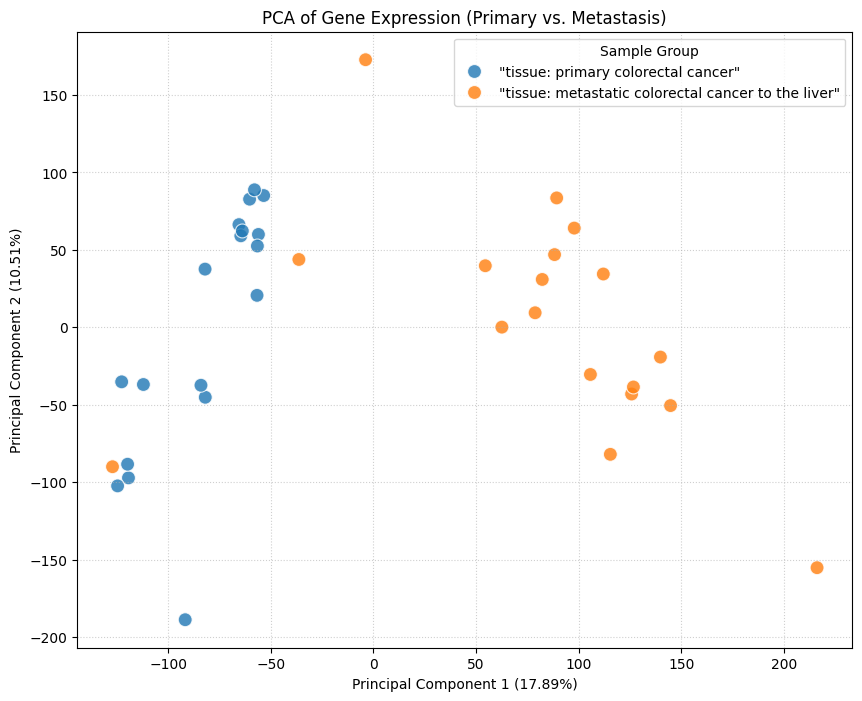

Explained variance ratio by principal components:
PC1: 17.89%
PC2: 10.51%


In [64]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Use the log2-transformed expression data for PCA
pca_data = EXPRESSION_DATA_LOG2.copy()

# Instantiate PCA - we'll visualize the first two principal components
pca = PCA(n_components=2)

# Fit PCA to the data and transform it
pca_result = pca.fit_transform(pca_data)

# Create a DataFrame for plotting the PCA results
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
pca_df.index = pca_data.index # Retain sample IDs as index

# Add the grouping information from COL_DATA to the PCA DataFrame
pca_df['group'] = COL_DATA[GROUP_COLUMN]

# Plotting the PCA
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='group', # Color points by their group (primary vs. metastasis)
    s=100, # Size of points
    alpha=0.8
)

plt.title('PCA of Gene Expression (Primary vs. Metastasis)')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title='Sample Group')
plt.show()

print("Explained variance ratio by principal components:")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {ratio*100:.2f}%")

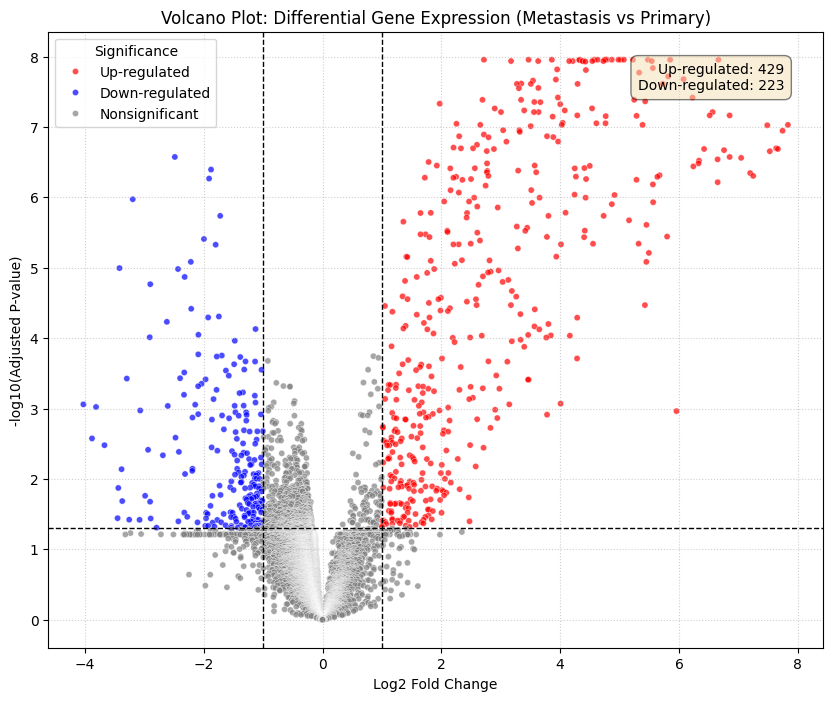

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Now using ALL_GENES_LIMMA_RESULTS for the Volcano Plot
# It contains 'logFC' (log2 fold change) and 'adj.P.Val' (adjusted p-value)

# Define significance thresholds
LOG2_FOLD_CHANGE_THRESHOLD = 1.0 # e.g., |log2FC| >= 1 means 2-fold change
ADJ_P_VALUE_THRESHOLD = 0.05     # Adjusted p-value <= 0.05

# Create a 'significant' column
# Operate on a copy to avoid SettingWithCopyWarning if ALL_GENES_LIMMA_RESULTS is a view
plot_data = ALL_GENES_LIMMA_RESULTS.copy()

plot_data['significant'] = (
    (plot_data['adj.P.Val'] < ADJ_P_VALUE_THRESHOLD) &
    (np.abs(plot_data['logFC']) > LOG2_FOLD_CHANGE_THRESHOLD)
)

# Create a 'direction' column for coloring
plot_data['direction'] = 'Nonsignificant'
plot_data.loc[
    (plot_data['significant']) & (plot_data['logFC'] > LOG2_FOLD_CHANGE_THRESHOLD),
    'direction'
] = 'Up-regulated'
plot_data.loc[
    (plot_data['significant']) & (plot_data['logFC'] < -LOG2_FOLD_CHANGE_THRESHOLD),
    'direction'
] = 'Down-regulated'

# Volcano Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=plot_data,
    x='logFC',
    y=-np.log10(plot_data['adj.P.Val']),
    hue='direction',
    palette={'Up-regulated': 'red', 'Down-regulated': 'blue', 'Nonsignificant': 'grey'},
    s=20, alpha=0.7
)

# Add thresholds lines
plt.axvline(x=LOG2_FOLD_CHANGE_THRESHOLD, color='black', linestyle='--', lw=1)
plt.axvline(x=-LOG2_FOLD_CHANGE_THRESHOLD, color='black', linestyle='--', lw=1)
plt.axhline(y=-np.log10(ADJ_P_VALUE_THRESHOLD), color='black', linestyle='--', lw=1)

# Labels and title
plt.xlabel('Log2 Fold Change')
plt.ylabel('-log10(Adjusted P-value)')
plt.title('Volcano Plot: Differential Gene Expression (Metastasis vs Primary)')

# Annotate the number of significant genes
num_up = (plot_data['direction'] == 'Up-regulated').sum()
num_down = (plot_data['direction'] == 'Down-regulated').sum()
plt.text(
    0.95,
    0.95,
    f'Up-regulated: {num_up}\nDown-regulated: {num_down}',
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5)
)

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title='Significance')
plt.show()

/tmp/ipykernel_1321/1599442724.py:15: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  violin_data['Group'] = violin_data['Group'].replace({


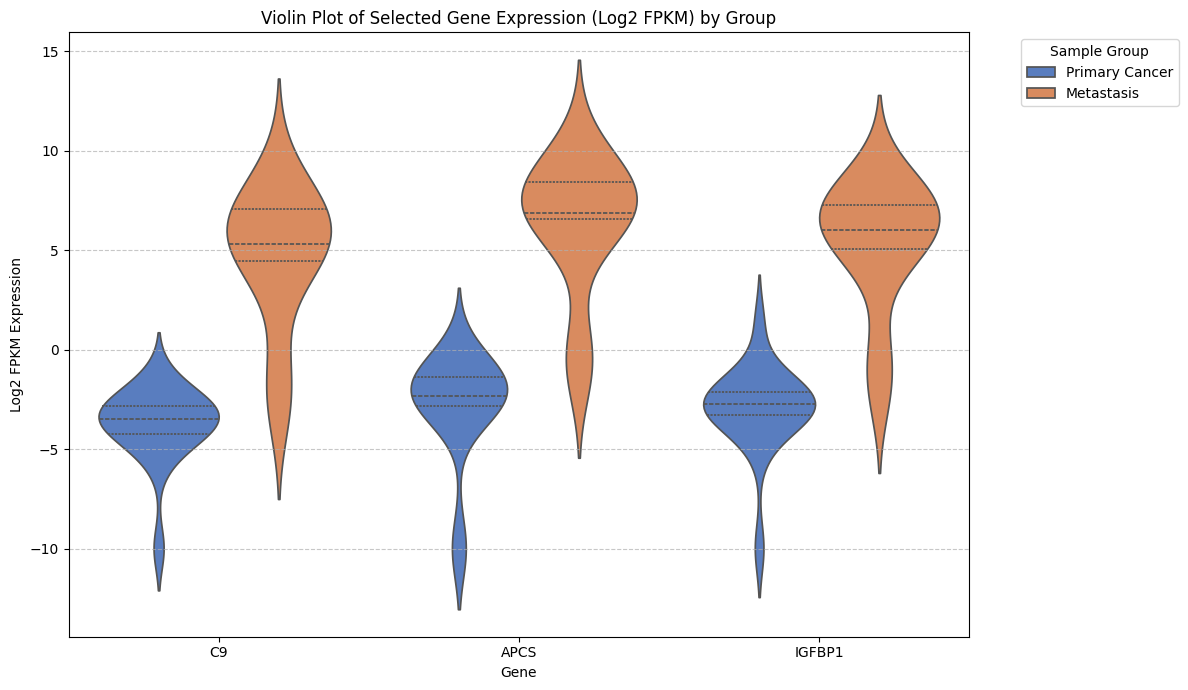

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the genes for the violin plot
genes_to_plot = ['C9', 'APCS', 'IGFBP1']

# Filter the log2-transformed expression data for these genes
violin_data = EXPRESSION_DATA_LOG2[genes_to_plot].copy()

# Add the group information from COL_DATA
violin_data['Group'] = COL_DATA[GROUP_COLUMN]

# Map the labels to a more readable format for the plot
violin_data['Group'] = violin_data['Group'].replace({
    PRIMARY_CANCER_LABEL: 'Primary Cancer',
    METASTASIS_LABEL: 'Metastasis'
})

# Melt the DataFrame to long format for seaborn.violinplot
violin_data_melted = violin_data.melt(id_vars=['Group'], var_name='Gene', value_name='Log2_Expression')

# Create the violin plot
plt.figure(figsize=(12, 7))
sns.violinplot(
    data=violin_data_melted,
    x='Gene',
    y='Log2_Expression',
    hue='Group',
    inner='quartile', # Show quartiles inside the violins
    palette='muted' # A pleasant color palette
)

plt.title('Violin Plot of Selected Gene Expression (Log2 FPKM) by Group')
plt.xlabel('Gene')
plt.ylabel('Log2 FPKM Expression')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Sample Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [70]:
import sys
!{sys.executable} -m pip install gprofiler-official

## Step 11: Functional Enrichment Analysis using gProfiler

Functional enrichment analysis helps us understand the biological meaning behind a list of genes. We'll use gProfiler, a powerful tool that queries various databases (Gene Ontology, KEGG, Reactome, etc.) to identify over-represented biological terms within our set of significant differentially expressed genes.

In [74]:
import sys
# Uninstall the current version of gprofiler-official
!{sys.executable} -m pip uninstall gprofiler-official -y

# Install the recommended older version
!{sys.executable} -m pip install gprofiler-official==0.3.5

from gprofiler import GProfiler
import pandas as pd

# Initialize gProfiler
gp = GProfiler(return_dataframe=True)

# Perform enrichment analysis
# organism: 'hsapiens' for human
# significant_gene_ids: List of gene IDs obtained from limma results
# sources: Specify which databases to query (e.g., GO:BP for Biological Process, KEGG, REAC for Reactome)
print(f"Performing enrichment analysis for {len(significant_gene_ids)} significant genes...")
enrichment_results = gp.enrich(query=significant_gene_ids,
                                 organism='hsapiens',
                                 sources=['GO:BP', 'KEGG', 'REAC'])

print("Enrichment analysis complete. Displaying top results:")
display(enrichment_results.head(15))

# Store the results
FUNCTIONAL_ENRICHMENT_RESULTS = enrichment_results

Found existing installation: gprofiler-official 0.3.5
Uninstalling gprofiler-official-0.3.5:
  Successfully uninstalled gprofiler-official-0.3.5
  Using cached gprofiler_official-0.3.5-py3-none-any.whl
Performing enrichment analysis for 652 significant genes...


AttributeError: enrich is not an attribute of GProfiler

In [72]:
import sys
# Uninstall the current version of gprofiler-official
!{sys.executable} -m pip uninstall gprofiler-official -y

# Install the recommended older version
!{sys.executable} -m pip install gprofiler-official==0.3.5

Found existing installation: gprofiler-official 1.0.0
Uninstalling gprofiler-official-1.0.0:
  Successfully uninstalled gprofiler-official-1.0.0
  Preparing metadata (setup.py) ... done
  Created wheel for gprofiler-official: filename=gprofiler_official-0.3.5-py3-none-any.whl size=14673 sha256=51d79ff5d6d67d1056e6b802234ad76b40dd17ac67aaf4ace46ce48910a44b02
  Stored in directory: /root/.cache/pip/wheels/db/23/06/112e150b8bcf134bddfaa42717e60d663e21bda20854219b09
Successfully built gprofiler-official


In [73]:
from gprofiler import GProfiler
import pandas as pd

# Initialize gProfiler
gp = GProfiler(return_dataframe=True)

# Perform enrichment analysis
# organism: 'hsapiens' for human
# significant_gene_ids: List of gene IDs obtained from limma results
# sources: Specify which databases to query (e.g., GO:BP for Biological Process, KEGG, REAC for Reactome)
print(f"Performing enrichment analysis for {len(significant_gene_ids)} significant genes...")
enrichment_results = gp.enrich(query=significant_gene_ids,
                                 organism='hsapiens',
                                 sources=['GO:BP', 'KEGG', 'REAC'])

print("Enrichment analysis complete. Displaying top results:")
display(enrichment_results.head(15))

# Store the results
FUNCTIONAL_ENRICHMENT_RESULTS = enrichment_results

Performing enrichment analysis for 652 significant genes...


AttributeError: enrich is not an attribute of GProfiler